In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Neural Network Model (positive solution via exp)

In [5]:
class PINN(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        raw = self.net(x)
        return torch.exp(raw)  # enforce u >= 0 (no abs bias)

# 2. Full Infinity Laplacian (n-dim)
# Δ∞u = ∇u^T (D^2 u) ∇u

In [6]:
def infinity_laplacian(u, x):
    grads = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]  # (N, d)
    lap = torch.zeros_like(u)

    for i in range(x.shape[1]):
        grad_i = grads[:, i:i+1]
        grad2_i = torch.autograd.grad(grad_i, x, grad_outputs=torch.ones_like(grad_i), create_graph=True)[0]
        for j in range(x.shape[1]):
            lap += grads[:, i:i+1] * grads[:, j:j+1] * grad2_i[:, j:j+1]

    return lap

# 3. PDE Residual

In [7]:
def pde_residual(model, x, params):
    c, q, lam, a, p = params

    x.requires_grad_(True)
    u = model(x)

    grad_u = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    lap_inf = infinity_laplacian(u, x)

    lhs = -lap_inf + c * torch.norm(grad_u, dim=1, keepdim=True) ** q
    rhs = lam * torch.norm(x, dim=1, keepdim=True) ** a * u ** p

    return lhs - rhs, u, grad_u


# 4. Boundary Condition (avoid trivial solution)

In [8]:
def boundary_loss(model):
    x0 = torch.zeros((1,1))
    return (model(x0) - 1.0) ** 2

# 5. Training

In [9]:
def train_pinn(q_value, dim=1, epochs=4000):
    model = PINN(in_dim=dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    params = (0.5, q_value, 1.0, 0.0, 2.5)

    # sample domain
    x = torch.linspace(-2, 2, 200).unsqueeze(1)
    if dim > 1:
        x = torch.randn(200, dim)

    losses, norms = [], []

    for epoch in range(epochs):
        optimizer.zero_grad()

        residual, u, grad_u = pde_residual(model, x, params)

        loss_pde = torch.mean(residual**2)
        loss_bc = boundary_loss(model)

        loss = loss_pde + loss_bc

        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        norms.append(torch.mean(u).item())

        if epoch % 500 == 0:
            print(f"[q={q_value}] Epoch {epoch}, Loss: {loss.item():.6f}")

    return model, x.detach(), losses, norms


# 6. Phase Study

In [10]:
def phase_study(q_values, dim=1):
    results = {}

    for q in q_values:
        print(f"\nTraining for q = {q}")
        model, x, losses, norms = train_pinn(q, dim)

        with torch.no_grad():
            u_pred = model(x).numpy()

        results[q] = {
            "x": x.numpy(),
            "u": u_pred,
            "loss": losses,
            "norm": norms
        }

    return results


# 7. Scaling Analysis (estimate decay rate)

In [11]:
def estimate_decay(x, u):
    r = np.linalg.norm(x, axis=1)
    mask = r > 0.5
    r = r[mask]
    u = u[mask]

    log_r = np.log(r + 1e-8)
    log_u = np.log(np.abs(u) + 1e-8)

    coeff = np.polyfit(log_r, log_u, 1)
    return coeff[0]  # slope ~ -beta

# 8. Visualization

In [13]:
def plot_results(results):
    plt.figure(figsize=(12,5))
    for q, data in results.items():
        plt.plot(data["x"], data["u"], label=f"q={q}")
    plt.title("Solution vs q (Phase Transition)")
    plt.legend(); plt.grid(); plt.show()


def plot_norms(results):
    plt.figure(figsize=(10,4))
    for q, data in results.items():
        plt.plot(data["norm"], label=f"q={q}")
    plt.title("||u|| convergence")
    plt.legend(); plt.grid(); plt.show()


# 9. Run


Training for q = 1
[q=1] Epoch 0, Loss: 0.488522
[q=1] Epoch 500, Loss: 0.015677
[q=1] Epoch 1000, Loss: 0.009574
[q=1] Epoch 1500, Loss: 0.005982
[q=1] Epoch 2000, Loss: 0.003785
[q=1] Epoch 2500, Loss: 0.001413
[q=1] Epoch 3000, Loss: 0.000910
[q=1] Epoch 3500, Loss: 0.000944

Training for q = 2
[q=2] Epoch 0, Loss: 1.501466
[q=2] Epoch 500, Loss: 0.027488
[q=2] Epoch 1000, Loss: 0.014604
[q=2] Epoch 1500, Loss: 0.010923
[q=2] Epoch 2000, Loss: 0.008366
[q=2] Epoch 2500, Loss: 0.005638
[q=2] Epoch 3000, Loss: 0.003574
[q=2] Epoch 3500, Loss: 0.002659

Training for q = 3
[q=3] Epoch 0, Loss: 7.797196
[q=3] Epoch 500, Loss: 0.111383
[q=3] Epoch 1000, Loss: 0.061843
[q=3] Epoch 1500, Loss: 0.051377
[q=3] Epoch 2000, Loss: 0.046456
[q=3] Epoch 2500, Loss: 0.040731
[q=3] Epoch 3000, Loss: 0.034352
[q=3] Epoch 3500, Loss: 0.026820

Training for q = 4
[q=4] Epoch 0, Loss: 2.478343
[q=4] Epoch 500, Loss: 0.055453
[q=4] Epoch 1000, Loss: 0.031537
[q=4] Epoch 1500, Loss: 0.026017
[q=4] Epoch 

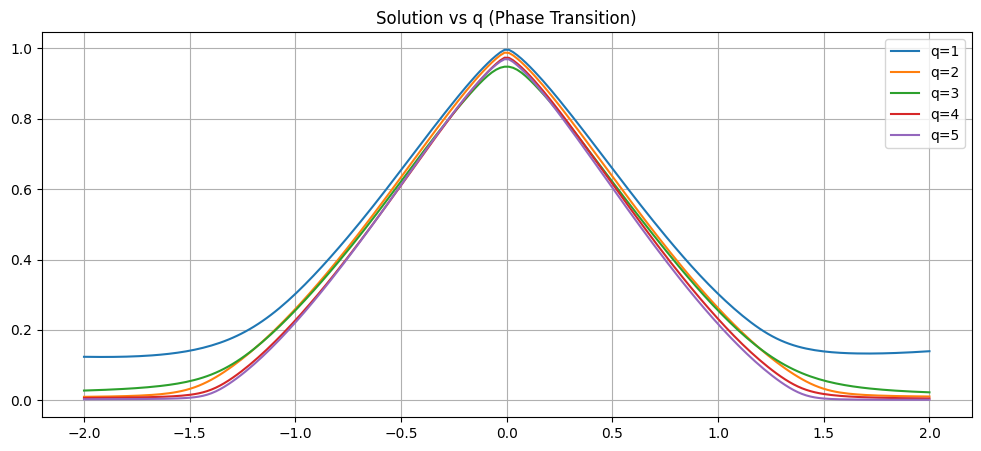

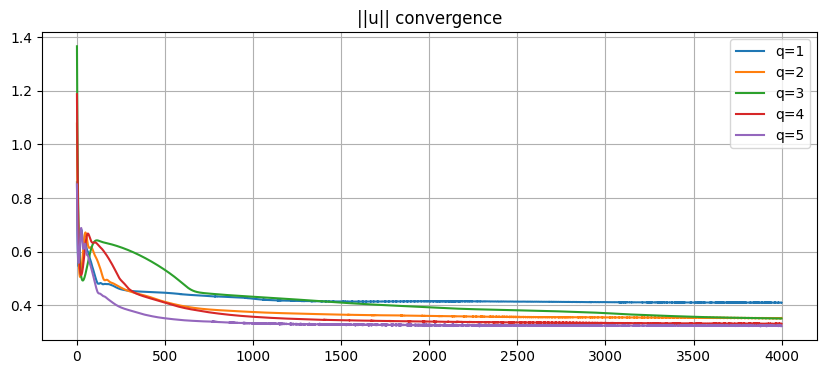

q=1, estimated decay exponent beta ≈ 1.431
q=2, estimated decay exponent beta ≈ 3.625
q=3, estimated decay exponent beta ≈ 2.751
q=4, estimated decay exponent beta ≈ 4.186
q=5, estimated decay exponent beta ≈ 5.330


/tmp/ipykernel_31039/1647245100.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  beta = float(beta)  # ✅ FIX LỖI Ở ĐÂY


In [15]:
if __name__ == "__main__":
    q_values = [1,2,3,4,5]
    results = phase_study(q_values, dim=1)

    plot_results(results)
    plot_norms(results)

    # scaling verification
    for q, data in results.items():
        beta = estimate_decay(data["x"], data["u"])
        beta = float(beta)  # ✅ FIX LỖI Ở ĐÂY
        print(f"q={q}, estimated decay exponent beta ≈ {-beta:.3f}")